In [1]:
# ══════════════════════════════════════════════════════════════
# Логика пайплайна
# ══════════════════════════════════════════════════════════════
#
# 1. ВЫБОРКА СРЕЗОВ (adaptive step)
#    Извлекаем срезы с логарифмическим шагом:
#      step = max(1, log2(n / base))
#    Пример (base=50): 50 → step=1, 200 → step=2, 500 → step=3.
#
# 2. ФОРМИРОВАНИЕ ОКОН
#    Срезы группируются в окна по GROUP_SIZE штук с шагом GROUP_STRIDE.
#    При GROUP_SIZE=1 каждое окно — один слайс.
#    При GROUP_SIZE>1 и STRIDE<SIZE — окна перекрываются,
#    что предотвращает потерю патологии на границе.
#    Пример (GROUP_SIZE=12, GROUP_STRIDE=8):
#      окно 1: [0..11], окно 2: [8..19], overlap = 4 среза.
#
# 3. HU-ОКНА
#    Каждая проекция прогоняется в нескольких режимах плотности:
#    - Lung (-600/1500)     — лёгочная паренхима, дыхательные пути
#    - Soft tissue (40/400) — средостение, сосуды, лимфоузлы, органы
#    Набор настраивается через EVAL_COMBOS.
#
# 4. ПРОЕКЦИИ (extract_planes)
#    Axial — базовая и обязательная.
#    Coronal/sagittal — опционально, через EVAL_COMBOS.
#    Для каждой пары (проекция × HU) прогоняем пункты 5–6.
#
# 5. ИНФЕРЕНС (model.run)
#    Каждое окно подаётся в VLM → structured output:
#      {
#        "analysis":       "...",        ← CoT-рассуждение
#        "is_abnormal":    true/false,
#        "confidence":     1/2/3,        ← 1: не репортабельно,
#                                           2: нельзя исключить,
#                                           3: достоверная находка
#        "pathology_type": "..." | null
#      }
#
# 6. АГРЕГАЦИЯ ВНУТРИ КОМБИНАЦИИ
#    Для каждой пары (например, axial + Lung) вычисляем:
#    - max_conf       = макс. confidence среди abnormal-окон
#    - max_run        = макс. число abnormal-окон подряд
#    - abnormal_ratio = доля abnormal-окон от общего числа
#
# 7. ФИНАЛЬНЫЙ ВЕРДИКТ ПО ИССЛЕДОВАНИЮ
#    Вердикт ABNORMAL, если в ЛЮБОЙ комбинации (проекция × HU)
#    сработало хотя бы одно правило из RULES.
#
#    Каждое правило — словарь условий, ВСЕ условия внутри через AND.
#    Правила между собой — через OR.
#
#    RULES = [
#        {"conf": 3},                # достоверная находка
#        {"conf": 2, "run": 2},      # вероятная + подтверждена соседями
#        {"ratio": 0.3},             # диффузная патология
#    ]
#
#    Пример: правило {"conf": 2, "run": 2} сработает только если
#    max_conf >= 2 И max_run >= 2 одновременно.
#
#    Иначе → NORMAL.
# ══════════════════════════════════════════════════════════════

# Imports and Model initialization

In [2]:
%load_ext autoreload
%autoreload 2

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

import json
import nibabel as nib

import sys
import zipfile
import time
import random
import numpy as np
import pandas as pd
import pydicom
from tqdm import tqdm
from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import roc_auc_score, confusion_matrix

import nibabel as nib

sys.path.insert(0, "/home/a-lugovoi/Git/medscreen/dev")
from model import CTScreener
from preprocessing import extract_planes, prepare_uniform, extract_planes
os.chdir("/home/a-lugovoi/Git/medscreen/dev")

In [3]:
model = CTScreener(
    data_dir='/home/a-lugovoi/Git/medscreen/dev/tmp',
    gpu_memory=0.75,
    max_model_len=4096,
    max_tokens=512
)

2026-03-24 16:42:35 [MODEL] INFO: Загрузка модели 'google/medgemma-1.5-4b-it'...


INFO 03-24 16:42:35 [utils.py:253] non-default args: {'trust_remote_code': True, 'allowed_local_media_path': '/home/a-lugovoi/Git/medscreen/dev/tmp', 'dtype': 'bfloat16', 'seed': None, 'max_model_len': 4096, 'gpu_memory_utilization': 0.75, 'disable_log_stats': True, 'model': 'google/medgemma-1.5-4b-it'}


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


WARNING 03-24 16:42:35 [arg_utils.py:1175] `seed=None` is equivalent to `seed=0` in V1 Engine. You will no longer be allowed to pass `None` in v0.13.
INFO 03-24 16:42:36 [model.py:637] Resolved architecture: Gemma3ForConditionalGeneration
INFO 03-24 16:42:36 [model.py:1750] Using max model len 4096
INFO 03-24 16:42:36 [scheduler.py:228] Chunked prefill is enabled with max_num_batched_tokens=8192.
(EngineCore_DP0 pid=2867319) INFO 03-24 16:42:43 [core.py:93] Initializing a V1 LLM engine (v0.12.0) with config: model='google/medgemma-1.5-4b-it', speculative_config=None, tokenizer='google/medgemma-1.5-4b-it', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.bfloat16, max_seq_len=4096, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto, device_config=cuda, structured_o

(EngineCore_DP0 pid=2867319) Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


...

Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]


(EngineCore_DP0 pid=2867319) INFO 03-24 16:43:07 [default_loader.py:308] Loading weights took 3.03 seconds
(EngineCore_DP0 pid=2867319) INFO 03-24 16:43:08 [gpu_model_runner.py:3549] Model loading took 8.5834 GiB memory and 4.235431 seconds
(EngineCore_DP0 pid=2867319) INFO 03-24 16:43:08 [gpu_model_runner.py:4306] Encoder cache will be initialized with a budget of 8192 tokens, and profiled with 31 image items of the maximum feature size.
(EngineCore_DP0 pid=2867319) INFO 03-24 16:43:18 [backends.py:655] Using cache directory: /home/a-lugovoi/.cache/vllm/torch_compile_cache/369898eb3c/rank_0_0/backbone for vLLM's torch.compile
(EngineCore_DP0 pid=2867319) INFO 03-24 16:43:18 [backends.py:715] Dynamo bytecode transform time: 8.18 s
(EngineCore_DP0 pid=2867319) INFO 03-24 16:43:23 [backends.py:216] Directly load the compiled graph(s) for dynamic shape from the cache, took 3.710 s
(EngineCore_DP0 pid=2867319) INFO 03-24 16:43:25 [monitor.py:34] torch.compile takes 11.89 s in total
(Engine

Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 51/51 [00:02<00:00, 19.37it/s]
Capturing CUDA graphs (decode, FULL): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 35/35 [00:01<00:00, 23.81it/s]


(EngineCore_DP0 pid=2867319) INFO 03-24 16:43:32 [gpu_model_runner.py:4466] Graph capturing finished in 5 secs, took 2.27 GiB
(EngineCore_DP0 pid=2867319) INFO 03-24 16:43:32 [core.py:254] init engine (profile, create kv cache, warmup model) took 24.24 seconds
INFO 03-24 16:43:35 [llm.py:343] Supported tasks: ['generate']


2026-03-24 16:43:35 [MODEL] INFO: Модель загружена за 60.9с


In [4]:
def show_metrics(df):
    y_true = (df["label"] == "ABNORMAL").astype(int)
    y_pred = (df["verdict"] == "ABNORMAL").astype(int)
    
    # Берём максимальный ratio среди всех комбинаций для ROC AUC
    ratio_cols = [c for c in df.columns if c.endswith("_ratio")]
    max_ratio = df[ratio_cols].max(axis=1) if ratio_cols else y_pred.astype(float)
    
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    metrics = {
        "Accuracy": (tp + tn) / (tp + tn + fp + fn),
        "Sensitivity": tp / (tp + fn) if (tp + fn) > 0 else 0,
        "Specificity": tn / (tn + fp) if (tn + fp) > 0 else 0,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) > 0 else 0,
        "NPV": tn / (tn + fn) if (tn + fn) > 0 else 0,
    }
    if y_true.nunique() > 1:
        metrics["ROC AUC"] = roc_auc_score(y_true, max_ratio)
    
    display(pd.DataFrame({"Metric": metrics.keys(), "Value": [round(v, 3) for v in metrics.values()]}))
    
    fig, ax = plt.subplots(figsize=(5, 4))
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
    annot = [[f"{v}\n({p:.1%})" for v, p in zip(row, prow)] for row, prow in zip(cm, cm_pct)]
    sns.heatmap(cm, annot=annot, fmt="", xticklabels=["NORMAL", "ABNORMAL"],
                yticklabels=["NORMAL", "ABNORMAL"], cmap="Blues", ax=ax, cbar=False)
    ax.set(xlabel="Predicted", ylabel="True", title="Confusion Matrix")
    plt.tight_layout()
    plt.show()
    
    if "group" in df.columns and df["group"].nunique() > 1:
        summary = df.groupby("group").agg(
            total=("file", "count"),
            predicted_abnormal=("verdict", lambda x: (x == "ABNORMAL").sum()),
            accuracy=("verdict", lambda x: (x.values == df.loc[x.index, "label"].values).mean()),
            mean_max_ratio=("file", lambda x: max_ratio.loc[x.index].mean()),
            mean_time=("time", "mean"),
        ).round(3)
        print("\nPer-group summary:")
        display(summary)


def load_dicom_volume(study_dir):
    """Загружает серию DICOM как 3D volume (Z, H, W) в единицах HU."""
    dicom_dir = None
    for root, dirs, files in os.walk(study_dir):
        if any(f.lower().endswith('.dcm') for f in files):
            dicom_dir = root
            break

    if not dicom_dir:
        return None

    files = [os.path.join(dicom_dir, f) for f in os.listdir(dicom_dir)
             if f.lower().endswith('.dcm')]
    slices = [pydicom.dcmread(f) for f in files]
    slices.sort(key=lambda s: float(s.ImagePositionPatient[2])
                if hasattr(s, 'ImagePositionPatient') else 0)

    volume = np.stack([
        s.pixel_array.astype(np.float32) * float(getattr(s, 'RescaleSlope', 1))
        + float(getattr(s, 'RescaleIntercept', 0))
        for s in slices
    ])
    return volume

def longest_run(labels):
    best = cur = 0
    for x in labels:
        if x:
            cur += 1
            best = max(best, cur)
        else:
            cur = 0
    return best

def check_rules(max_conf, max_run, ratio, rules):
    for rule in rules:
        match = True
        if "conf" in rule and max_conf < rule["conf"]:
            match = False
        if "run" in rule and max_run < rule["run"]:
            match = False
        if "ratio" in rule and ratio < rule["ratio"]:
            match = False
        if match:
            return True, rule
    return False, None

# MosMedData: Chest CT Scans with Signs of COVID-19
- https://mosmed.ai/en/datasets/datasets/covid191110/

## unzip

In [4]:
archive = Path("data/mosmed/COVID19_1110.zip")
data_dir = archive.with_suffix("")  # "data/mosmed/COVID19_1110"

# 1. Extract archive to the parent directory
with zipfile.ZipFile(archive, 'r') as z:
    z.extractall(archive.parent)

# 2. Move CT-X folders up one level and remove the intermediate "studies" directory
studies_dir = data_dir / "studies"
if studies_dir.exists():
    for folder in studies_dir.iterdir():
        folder.rename(data_dir / folder.name)
    studies_dir.rmdir()

# 3. Print the resulting directory structure
print("Structure:")
for folder in sorted(d for d in data_dir.iterdir() if d.is_dir()):
    files_count = len(list(folder.glob("*.nii.gz")))
    print(f"  {folder.name}: {files_count} files")

Structure:
  CT-0: 254 files
  CT-1: 684 files
  CT-2: 125 files
  CT-3: 45 files
  CT-4: 2 files
  masks: 50 files


## visualization

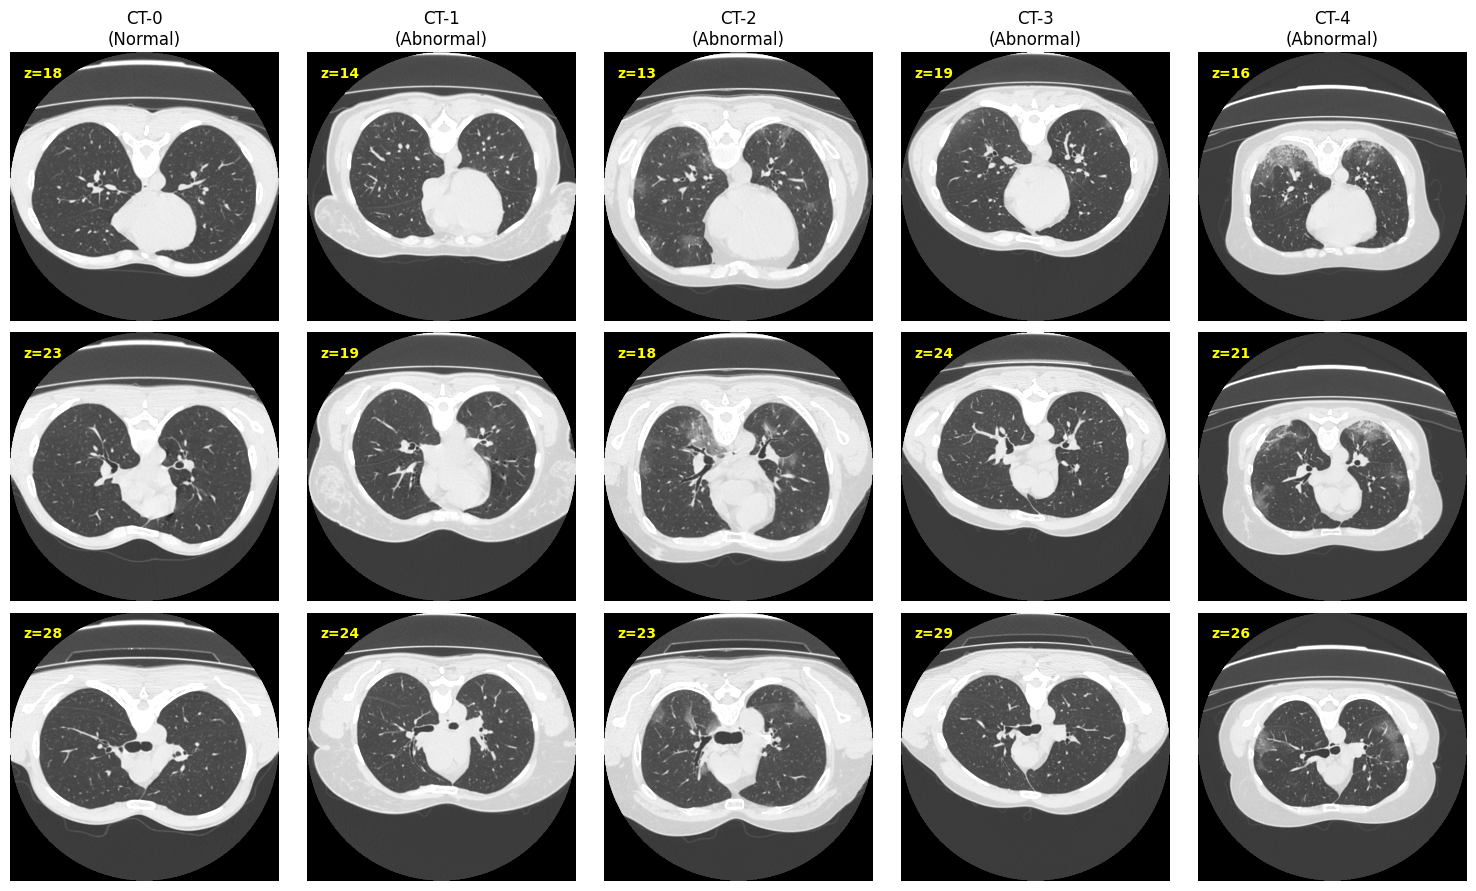

In [3]:
DATA_DIR = "data/mosmed/COVID19_1110"
groups = ["CT-0", "CT-1", "CT-2", "CT-3", "CT-4"]
n_slices = 3  # Number of slices per study
step = 5      # Step between slices (in pixels along Z axis)

fig, axes = plt.subplots(n_slices, len(groups), figsize=(15, 3 * n_slices))

for col, group in enumerate(groups):
    group_dir = os.path.join(DATA_DIR, group)
    fname = next(f for f in os.listdir(group_dir) if f.endswith(".nii.gz"))
    vol = nib.load(os.path.join(group_dir, fname)).get_fdata()
    
    z_center = vol.shape[2] // 2
    # Select n_slices around the center
    z_indices = [z_center - step, z_center, z_center + step]
    
    for row, z in enumerate(z_indices):
        ax = axes[row, col]
        slice_2d = vol[:, :, z]
        
        # Lung window: center=-600, width=1500
        ax.imshow(slice_2d.T, cmap="gray", vmin=-1350, vmax=150)
        
        # Add titles only to the top row
        if row == 0:
            ax.set_title(f"{group}\n({'Normal' if group=='CT-0' else 'Abnormal'})")
            
        ax.text(0.05, 0.95, f"z={z}", color="yellow", transform=ax.transAxes, 
                verticalalignment='top', fontsize=10, fontweight='bold')
        ax.axis("off")

plt.tight_layout()
plt.show()

## run

In [10]:
PROMPT = """\
You are an expert CT radiologist. Carefully examine these chest/abdomen CT slices.

Look carefully for ANY pathological findings — anything a radiologist would flag in a clinical report.

Important:
- Normal anatomical variants are NOT pathology
- Age-related degenerative changes are NOT pathology
- Artifacts, noise, motion blur are NOT pathology
- Report ABNORMAL only for true structural pathology
- If is_abnormal is false, set confidence to 1

First, describe what you see in the "analysis" field. Then give your verdict.

{
  "analysis": "what you observe in these slices",
  "is_abnormal": true/false,
  "confidence": 1 (not reportable) / 2 (cannot exclude) / 3 (definite finding),
  "pathology_type": "covid" / "cancer" / "abdominal" / "other" / null
}
"""

EVAL_COMBOS = [
    ("axial", -600, 1500),   # легочное окно
    ("axial", 40, 400),      # мягкотканное окно
]

BASE = 50
GROUP_SIZE = 8
GROUP_STRIDE = GROUP_SIZE

RULES = [
    # {"conf": 3},              # достоверная находка
    # {"conf": 2, "run": 2},    # вероятная + подтверждена соседями
    {"ratio": 0.3},           # диффузная патология
]

In [11]:
DATA_DIR = "data/mosmed/COVID19_1110"
GT = {"CT-0": "NORMAL", "CT-1": "ABNORMAL", "CT-2": "ABNORMAL", "CT-3": "ABNORMAL", "CT-4": "ABNORMAL"}

SAMPLE = {"CT-0": 102, "CT-1": 50, "CT-2": 25, "CT-3": 25, "CT-4": 2}

random.seed(1)
test_files = []
for group, label in GT.items():
    group_dir = os.path.join(DATA_DIR, group)
    files = [f for f in sorted(os.listdir(group_dir)) if f.endswith(".nii.gz")]
    n = min(SAMPLE[group], len(files))
    sampled = random.sample(files, n)
    for f in sampled:
        test_files.append((os.path.join(group, f), label))
    print(f"  {group}: {n}/{len(files)} files")

random.shuffle(test_files)
print(f"\nTotal: {len(test_files)} files")

  CT-0: 102/254 files
  CT-1: 50/684 files
  CT-2: 25/125 files
  CT-3: 25/45 files
  CT-4: 2/2 files

Total: 204 files


In [12]:
SAVE_PATH = "results_covid.csv"

done = set()
if os.path.exists(SAVE_PATH):
    done = set(pd.read_csv(SAVE_PATH)["file"].tolist())
    print(f"Resume: {len(done)} already done")

for i, (fname, gt) in enumerate(test_files):
    if fname in done:
        continue

    print(f"\n[{i+1}/{len(test_files)}] {fname}")
    t0 = time.time()

    vol_3d = nib.load(os.path.join(DATA_DIR, fname)).get_fdata().astype(np.float32)
    all_planes = extract_planes(vol_3d)

    all_ratios, all_runs, all_confs = {}, {}, {}
    all_is_abnormal, all_ranges = {}, {}
    n_groups_total = 0

    for plane, center, width in EVAL_COMBOS:
        groups, ranges = prepare_uniform(
            all_planes[plane], center=center, width=width,
            group_size=GROUP_SIZE, group_stride=GROUP_STRIDE, base=BASE,
        )

        r = model.run(groups, prompt=PROMPT)
        key = f"{plane}_hu({center})"

        is_abn = r["is_abnormal"]
        confs = r["confidences"]
        abn_confs = [c for c, a in zip(confs, is_abn) if a]

        all_ratios[key] = r["abnormal_ratio"]
        all_runs[key] = longest_run(is_abn)
        all_confs[key] = max(abn_confs) if abn_confs else 0
        all_is_abnormal[key] = is_abn
        all_ranges[key] = ranges
        n_groups_total += len(groups)

    # === Финальный вердикт ===
    verdict = "NORMAL"
    triggered_rule = None
    triggered_key = None
    for key in all_ratios:
        hit, rule = check_rules(all_confs[key], all_runs[key], all_ratios[key], RULES)
        if hit:
            verdict = "ABNORMAL"
            triggered_rule = rule
            triggered_key = key
            break

    # === Вывод ===
    elapsed = round(time.time() - t0, 1)
    gt_str = f" (gt={gt})" if gt else ""
    match_str = ""
    if gt:
        match_str = " ✅" if verdict == gt else " ❌"

    print(f"  -> {verdict}{gt_str}{match_str} | {elapsed}s | groups={n_groups_total}")
    for key in all_ratios:
        n_abn = sum(all_is_abnormal[key])
        n_tot = len(all_is_abnormal[key])
        print(
            f"     {key}: {n_abn}/{n_tot} abnormal"
            f" | conf={all_confs[key]} run={all_runs[key]} ratio={all_ratios[key]:.2f}"
        )
    if triggered_rule:
        print(f"     triggered: {triggered_rule} on {triggered_key}")

    # === Сохранение ===
    row = {
        "file": fname,
        "group": fname.split("/")[0],
        "label": gt,
        "verdict": verdict,
        "triggered_rule": json.dumps(triggered_rule),
        "triggered_key": triggered_key,
        "time": elapsed,
        "n_groups_total": n_groups_total,
        **{f"{k}_ratio": v for k, v in all_ratios.items()},
        **{f"{k}_run": v for k, v in all_runs.items()},
        **{f"{k}_conf": v for k, v in all_confs.items()},
        **{f"{k}_is_abnormal": json.dumps(v) for k, v in all_is_abnormal.items()},
        **{f"{k}_ranges": json.dumps(v) for k, v in all_ranges.items()},
    }

    pd.DataFrame([row]).to_csv(
        SAVE_PATH, mode="a",
        header=not os.path.exists(SAVE_PATH), index=False,
    )
    done.add(fname)


[1/204] CT-1/study_0816.nii.gz


2026-03-24 12:34:13 [MODEL] INFO: ABNORMAL: 3/6 (50%) | 7s
2026-03-24 12:34:22 [MODEL] INFO: ABNORMAL: 1/6 (17%) | 7s


  -> ABNORMAL (gt=ABNORMAL) ✅ | 17.7s | groups=12
     axial_hu(-600): 3/6 abnormal | conf=3 run=3 ratio=0.50
     axial_hu(40): 1/6 abnormal | conf=3 run=1 ratio=0.17
     triggered: {'ratio': 0.3} on axial_hu(-600)

[2/204] CT-1/study_0492.nii.gz


2026-03-24 12:34:55 [MODEL] INFO: ABNORMAL: 3/5 (60%) | 31s
2026-03-24 12:35:02 [MODEL] INFO: ABNORMAL: 0/5 (0%) | 6s


  -> ABNORMAL (gt=ABNORMAL) ✅ | 39.9s | groups=10
     axial_hu(-600): 3/5 abnormal | conf=3 run=3 ratio=0.60
     axial_hu(40): 0/5 abnormal | conf=0 run=0 ratio=0.00
     triggered: {'ratio': 0.3} on axial_hu(-600)

[3/204] CT-0/study_0251.nii.gz


...

  -> ABNORMAL (gt=ABNORMAL) ✅ | 21.6s | groups=12
     axial_hu(-600): 4/6 abnormal | conf=3 run=4 ratio=0.67
     axial_hu(40): 1/6 abnormal | conf=3 run=1 ratio=0.17
     triggered: {'ratio': 0.3} on axial_hu(-600)

[203/204] CT-0/study_0104.nii.gz


2026-03-24 13:35:51 [MODEL] INFO: ABNORMAL: 1/6 (17%) | 8s
2026-03-24 13:36:04 [MODEL] INFO: ABNORMAL: 1/6 (17%) | 11s


  -> NORMAL (gt=NORMAL) ✅ | 24.8s | groups=12
     axial_hu(-600): 1/6 abnormal | conf=3 run=1 ratio=0.17
     axial_hu(40): 1/6 abnormal | conf=3 run=1 ratio=0.17

[204/204] CT-0/study_0134.nii.gz


2026-03-24 13:36:15 [MODEL] INFO: ABNORMAL: 1/6 (17%) | 8s
2026-03-24 13:36:27 [MODEL] INFO: ABNORMAL: 0/6 (0%) | 9s


  -> NORMAL (gt=NORMAL) ✅ | 23.1s | groups=12
     axial_hu(-600): 1/6 abnormal | conf=3 run=1 ratio=0.17
     axial_hu(40): 0/6 abnormal | conf=0 run=0 ratio=0.00


In [13]:
df = pd.read_csv(SAVE_PATH)
df.head(3)

,file,group,label,verdict,triggered_rule,triggered_key,time,n_groups_total,axial_hu(-600)_ratio,axial_hu(40)_ratio,axial_hu(-600)_run,axial_hu(40)_run,axial_hu(-600)_conf,axial_hu(40)_conf,axial_hu(-600)_is_abnormal,axial_hu(40)_is_abnormal,axial_hu(-600)_ranges,axial_hu(40)_ranges
0,CT-1/study_0816.nii.gz,CT-1,ABNORMAL,ABNORMAL,"{""ratio"": 0.3}",axial_hu(-600),17.7,12,0.5,0.166667,3,1,3,3,"[true, true, true, false, false, false]","[false, true, false, false, false, false]","[[0, 7], [8, 15], [16, 23], [24, 31], [32, 39]...","[[0, 7], [8, 15], [16, 23], [24, 31], [32, 39]..."
1,CT-1/study_0492.nii.gz,CT-1,ABNORMAL,ABNORMAL,"{""ratio"": 0.3}",axial_hu(-600),39.9,10,0.6,0.000000,3,0,3,0,"[true, true, true, false, false]","[false, false, false, false, false]","[[0, 7], [8, 15], [16, 23], [24, 31], [31, 38]]","[[0, 7], [8, 15], [16, 23], [24, 31], [31, 38]]"
2,CT-0/study_0251.nii.gz,CT-0,NORMAL,NORMAL,NaN,NaN,16.2,10,0.2,0.000000,1,0,3,0,"[false, true, false, false, false]","[false, false, false, false, false]","[[0, 7], [8, 15], [16, 23], [24, 31], [32, 39]]","[[0, 7], [8, 15], [16, 23], [24, 31], [32, 39]]"


,Metric,Value
0,Accuracy,0.828
1,Sensitivity,0.941
2,Specificity,0.716
3,PPV (Precision),0.768
4,NPV,0.924
5,ROC AUC,0.918


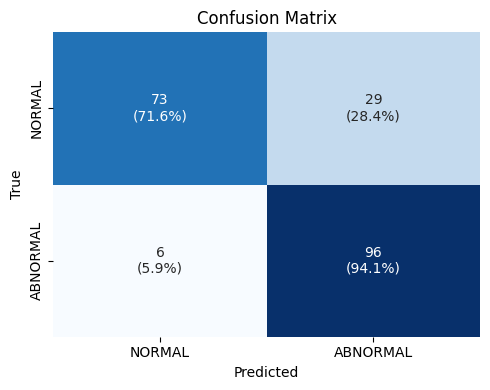


Per-group summary:


,total,predicted_abnormal,accuracy,mean_max_ratio,mean_time
group,,,,,
CT-0,102,29,0.716,0.222,18.144
CT-1,50,45,0.900,0.514,18.530
CT-2,25,25,1.000,0.580,19.380
CT-3,25,24,0.960,0.681,17.900
CT-4,2,2,1.000,0.650,16.650


In [14]:
show_metrics(df)

### Params tune

In [11]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_auc_score

df = pd.read_csv("results_covid.csv")

# Максимальный ratio среди всех комбо для каждого исследования
ratio_cols = [c for c in df.columns if c.endswith("_ratio")]
df["max_ratio"] = df[ratio_cols].max(axis=1)

# Максимальный conf и run
conf_cols = [c for c in df.columns if c.endswith("_conf")]
run_cols = [c for c in df.columns if c.endswith("_run")]
df["max_conf"] = df[conf_cols].max(axis=1)
df["max_run"] = df[run_cols].max(axis=1)

y_true = (df["label"] == "ABNORMAL").astype(int)

# === 1. Перебор ratio threshold ===
print("=" * 60)
print("RATIO THRESHOLD SWEEP")
print("=" * 60)
print(f"{'threshold':>10} {'acc':>6} {'sens':>6} {'spec':>6} {'ppv':>6} {'npv':>6} {'f1':>6}")
print("-" * 60)

best_f1 = 0
best_thresh = 0

for thresh in np.arange(0.05, 0.65, 0.05):
    y_pred = (df["max_ratio"] >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    acc = (tp + tn) / (tp + tn + fp + fn)
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    f1 = 2 * ppv * sens / (ppv + sens) if (ppv + sens) > 0 else 0
    
    marker = ""
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh
        marker = " <-- best"
    
    print(f"{thresh:>10.2f} {acc:>6.3f} {sens:>6.3f} {spec:>6.3f} {ppv:>6.3f} {npv:>6.3f} {f1:>6.3f}{marker}")

print(f"\nBest ratio threshold: {best_thresh:.2f} (F1={best_f1:.3f})")

# === 2. Перебор RULES комбинаций ===
print("\n" + "=" * 60)
print("RULES SWEEP")
print("=" * 60)

rules_variants = [
    ("ratio>=0.3",                lambda r: r["max_ratio"] >= 0.3),
    ("ratio>=0.2",                lambda r: r["max_ratio"] >= 0.2),
    ("ratio>=0.15",               lambda r: r["max_ratio"] >= 0.15),
    ("conf==3",                   lambda r: r["max_conf"] >= 3),
    ("conf>=2 & run>=2",          lambda r: (r["max_conf"] >= 2) & (r["max_run"] >= 2)),
    ("conf==3 | ratio>=0.3",      lambda r: (r["max_conf"] >= 3) | (r["max_ratio"] >= 0.3)),
    ("conf==3 | ratio>=0.2",      lambda r: (r["max_conf"] >= 3) | (r["max_ratio"] >= 0.2)),
    ("conf==3 | conf2+run2 | ratio>=0.3", lambda r: (r["max_conf"] >= 3) | ((r["max_conf"] >= 2) & (r["max_run"] >= 2)) | (r["max_ratio"] >= 0.3)),
    ("conf==3 | conf2+run2 | ratio>=0.2", lambda r: (r["max_conf"] >= 3) | ((r["max_conf"] >= 2) & (r["max_run"] >= 2)) | (r["max_ratio"] >= 0.2)),
    (f"ratio>={best_thresh:.2f} (best)", lambda r: r["max_ratio"] >= best_thresh),
]

print(f"{'rule':<40} {'acc':>6} {'sens':>6} {'spec':>6} {'ppv':>6} {'npv':>6} {'f1':>6}")
print("-" * 82)

for name, rule_fn in rules_variants:
    y_pred = rule_fn(df).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    acc = (tp + tn) / (tp + tn + fp + fn)
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    f1 = 2 * ppv * sens / (ppv + sens) if (ppv + sens) > 0 else 0
    
    print(f"{name:<40} {acc:>6.3f} {sens:>6.3f} {spec:>6.3f} {ppv:>6.3f} {npv:>6.3f} {f1:>6.3f}")

# === 3. ROC AUC ===
if y_true.nunique() > 1:
    auc = roc_auc_score(y_true, df["max_ratio"])
    print(f"\nROC AUC (max_ratio): {auc:.3f}")


RATIO THRESHOLD SWEEP
 threshold    acc   sens   spec    ppv    npv     f1
------------------------------------------------------------
      0.05  0.564  1.000  0.127  0.534  1.000  0.696 <-- best
      0.10  0.564  1.000  0.127  0.534  1.000  0.696
      0.15  0.583  0.990  0.176  0.546  0.947  0.704 <-- best
      0.20  0.775  0.961  0.588  0.700  0.938  0.810 <-- best
      0.25  0.824  0.951  0.696  0.758  0.934  0.843 <-- best
      0.30  0.828  0.941  0.716  0.768  0.924  0.846 <-- best
      0.35  0.863  0.863  0.863  0.863  0.863  0.863 <-- best
      0.40  0.863  0.863  0.863  0.863  0.863  0.863
      0.45  0.848  0.775  0.922  0.908  0.803  0.836
      0.50  0.848  0.775  0.922  0.908  0.803  0.836
      0.55  0.750  0.549  0.951  0.918  0.678  0.687
      0.60  0.642  0.304  0.980  0.939  0.585  0.459

Best ratio threshold: 0.35 (F1=0.863)

RULES SWEEP
rule                                        acc   sens   spec    ppv    npv     f1
---------------------------------------

In [25]:
from itertools import product

DEFAULT_PROMPT = """\
You are an expert CT radiologist. You are reviewing several consecutive axial CT slices.

Look carefully for ANY pathological findings, for example:
ground-glass opacity, consolidation, pleural effusion,
pneumothorax, atelectasis, nodules, masses,
or any other abnormality.

Important:
- Normal anatomical variants are NOT pathology
- Age-related changes alone are NOT pathology
- Report ABNORMAL only for true pathological findings

Decision rules:
- If ANY true pathology is present → verdict: ABNORMAL
- If lungs and structures are completely normal → verdict: NORMAL

Reasoning: one sentence, max 15 words, only what you see."""

# --- Parameter grid (only params that require re-inference) ---
prompts = {
    "default": DEFAULT_PROMPT,
    "sensitive": """\
You are an expert CT radiologist. You are reviewing several consecutive axial CT slices.

Carefully examine for any pathological findings, including subtle or early-stage ones such as faint ground-glass changes.

Important:
- Normal anatomical variants are NOT pathology
- Age-related changes alone are NOT pathology
- Artifacts and noise are NOT pathology
- Report ABNORMAL only for true pathological findings

Decision rules:
- If ANY true pathology is present, even minimal → verdict: ABNORMAL
- If lungs and structures are completely normal → verdict: NORMAL

Reasoning: one sentence, max 15 words, only what you see.""",
    "minimal": """\
You are an expert CT radiologist. You are reviewing several consecutive axial CT slices.

Carefully examine for any pathological findings, including subtle ones.

Important:
- Normal anatomical variants are NOT pathology
- Age-related changes alone are NOT pathology

Decision rules:
- If ANY true pathology is present → verdict: ABNORMAL
- If everything appears normal → verdict: NORMAL

Reasoning: one sentence, max 15 words, only what you see.""",
}

windows_grid = [
    {"center": -600, "width": 1500},  # standard lung
    {"center": -500, "width": 1000},  # narrow lung (better for GGO)
]

slicing_grid = [
    {"window_size": 20, "n_windows": 5},
    {"window_size": 15, "n_windows": 7},
]

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

# --- Fixed eval set (same samples for all experiments) ---
N_SAMPLES = 15  # per group, keep small for speed

random.seed(42)
eval_set = {}
for group in ["CT-0", "CT-1"]:
    group_dir = os.path.join("data/mosmed/COVID19_1110", group)
    files = sorted([f for f in os.listdir(group_dir) if f.endswith(".nii.gz")])
    eval_set[group] = random.sample(files, N_SAMPLES)

# --- Run grid search ---
all_results = []

combos = list(product(prompts.keys(), range(len(windows_grid)), range(len(slicing_grid))))
print(f"Total inference combos: {len(combos)} x {N_SAMPLES*2} files = {len(combos)*N_SAMPLES*2} runs")

for prompt_name, wi, si in tqdm(combos, desc="Grid search"):
    wp = windows_grid[wi]
    sp = slicing_grid[si]
    
    for group, files in eval_set.items():
        for fname in files:
            path = os.path.join("data/mosmed/COVID19_1110", group, fname)
            volume = nib.load(path).get_fdata().astype(np.float32)
            volume = np.transpose(volume, (2, 1, 0))
            
            r = model.run(volume, prompt=prompts[prompt_name], **wp, **sp)
            all_results.append({
                "prompt": prompt_name,
                "window": f"c={wp['center']},w={wp['width']}",
                "slicing": f"ws={sp['window_size']},nw={sp['n_windows']}",
                "group": group, "file": fname,
                "label": "NORMAL" if group == "CT-0" else "ABNORMAL",
                "abnormal_ratio": r["abnormal_ratio"],
            })

results_df = pd.DataFrame(all_results)
results_df.to_csv("grid_search_results.csv", index=False)

# --- Sweep thresholds offline ---
print("\n" + "="*80)
rows = []
for (pn, wn, sn), grp in results_df.groupby(["prompt", "window", "slicing"]):
    for t in thresholds:
        grp["pred"] = (grp["abnormal_ratio"] >= t).map({True: "ABNORMAL", False: "NORMAL"})
        ct0 = grp[grp["group"] == "CT-0"]
        ct1 = grp[grp["group"] == "CT-1"]
        spec = (ct0["pred"] == "NORMAL").mean()
        sens = (ct1["pred"] == "ABNORMAL").mean()
        rows.append({"prompt": pn, "window": wn, "slicing": sn,
                      "threshold": t, "spec_CT0": spec, "sens_CT1": sens,
                      "balanced": (spec + sens) / 2})

summary = pd.DataFrame(rows).sort_values("balanced", ascending=False)
print(summary.head(15).to_string(index=False))

Total inference combos: 12 x 30 files = 360 runs


Grid search:   0%|          | 0/12 [00:00<?, ?it/s]

2026-03-09 10:03:09,875 [MODEL] INFO: Result: NORMAL | ABNORMAL windows: 0/3 (0%) | Slices count: 60/46 (130%) | 5.8s
2026-03-09 10:03:16,443 [MODEL] INFO: Result: NORMAL | ABNORMAL windows: 0/2 (0%) | Slices count: 40/36 (111%) | 4.6s
2026-03-09 10:03:25,205 [MODEL] INFO: Result: ABNORMAL | ABNORMAL windows: 2/3 (67%) | Slices count: 60/44 (136%) | 5.7s
2026-03-09 10:03:33,981 [MODEL] INFO: Result: NORMAL | ABNORMAL windows: 0/3 (0%) | Slices count: 60/45 (133%) | 5.7s
2026-03-09 10:03:42,595 [MODEL] INFO: Result: NORMAL | ABNORMAL windows: 0/3 (0%) | Slices count: 60/45 (133%) | 5.7s
2026-03-09 10:03:51,197 [MODEL] INFO: Result: NORMAL | ABNORMAL windows: 0/3 (0%) | Slices count: 60/45 (133%) | 5.7s
2026-03-09 10:03:59,586 [MODEL] INFO: Result: NORMAL | ABNORMAL windows: 0/3 (0%) | Slices count: 60/43 (140%) | 5.6s
2026-03-09 10:04:08,199 [MODEL] INFO: Result: NORMAL | ABNORMAL windows: 0/3 (0%) | Slices count: 60/44 (136%) | 5.6s
2026-03-09 10:04:17,118 [MODEL] INFO: Result: NORMAL 


   prompt        window    slicing  threshold  spec_CT0  sens_CT1  balanced
sensitive c=-500,w=1000 ws=15,nw=7        0.3  0.866667  0.933333  0.900000
sensitive c=-500,w=1000 ws=15,nw=7        0.1  0.800000  0.933333  0.866667
  minimal c=-600,w=1500 ws=20,nw=5        0.4  0.933333  0.800000  0.866667
  minimal c=-600,w=1500 ws=20,nw=5        0.5  0.933333  0.800000  0.866667
sensitive c=-500,w=1000 ws=15,nw=7        0.2  0.800000  0.933333  0.866667
sensitive c=-600,w=1500 ws=20,nw=5        0.2  0.866667  0.800000  0.833333
sensitive c=-600,w=1500 ws=20,nw=5        0.1  0.866667  0.800000  0.833333
sensitive c=-600,w=1500 ws=20,nw=5        0.3  0.866667  0.800000  0.833333
sensitive c=-600,w=1500 ws=20,nw=5        0.4  0.933333  0.733333  0.833333
sensitive c=-500,w=1000 ws=20,nw=5        0.4  0.933333  0.733333  0.833333
sensitive c=-500,w=1000 ws=20,nw=5        0.5  0.933333  0.733333  0.833333
sensitive c=-600,w=1500 ws=20,nw=5        0.5  0.933333  0.733333  0.833333
sensitive c

In [26]:
summary = pd.DataFrame(rows).sort_values("balanced", ascending=False)
print(summary.head(15).to_string(index=False))

   prompt        window    slicing  threshold  spec_CT0  sens_CT1  balanced
sensitive c=-500,w=1000 ws=15,nw=7        0.3  0.866667  0.933333  0.900000
sensitive c=-500,w=1000 ws=15,nw=7        0.1  0.800000  0.933333  0.866667
  minimal c=-600,w=1500 ws=20,nw=5        0.4  0.933333  0.800000  0.866667
  minimal c=-600,w=1500 ws=20,nw=5        0.5  0.933333  0.800000  0.866667
sensitive c=-500,w=1000 ws=15,nw=7        0.2  0.800000  0.933333  0.866667
sensitive c=-600,w=1500 ws=20,nw=5        0.2  0.866667  0.800000  0.833333
sensitive c=-600,w=1500 ws=20,nw=5        0.1  0.866667  0.800000  0.833333
sensitive c=-600,w=1500 ws=20,nw=5        0.3  0.866667  0.800000  0.833333
sensitive c=-600,w=1500 ws=20,nw=5        0.4  0.933333  0.733333  0.833333
sensitive c=-500,w=1000 ws=20,nw=5        0.4  0.933333  0.733333  0.833333
sensitive c=-500,w=1000 ws=20,nw=5        0.5  0.933333  0.733333  0.833333
sensitive c=-600,w=1500 ws=20,nw=5        0.5  0.933333  0.733333  0.833333
sensitive c=

In [33]:
for t in [0.25, 0.27, 0.28, 0.29, 0.30, 0.31, 0.32, 0.33, 0.35]:
    df["pred"] = (df["abnormal_ratio"] >= t).map({True: "ABNORMAL", False: "NORMAL"})
    ct0 = df[df["group"] == "CT-0"]
    ct1 = df[df["group"] == "CT-1"]
    spec = (ct0["pred"] == "NORMAL").mean()
    sens = (ct1["pred"] == "ABNORMAL").mean()
    acc = (df["pred"] == df["label"]).mean()
    print(f"t={t:.2f} | acc: {acc:.0%} | CT-0 spec: {spec:.0%} | CT-1 sens: {sens:.0%}")


t=0.25 | acc: 83% | CT-0 spec: 79% | CT-1 sens: 80%
t=0.27 | acc: 82% | CT-0 spec: 82% | CT-1 sens: 77%
t=0.28 | acc: 82% | CT-0 spec: 82% | CT-1 sens: 77%
t=0.29 | acc: 82% | CT-0 spec: 82% | CT-1 sens: 77%
t=0.30 | acc: 82% | CT-0 spec: 82% | CT-1 sens: 77%
t=0.31 | acc: 82% | CT-0 spec: 82% | CT-1 sens: 77%
t=0.32 | acc: 82% | CT-0 spec: 82% | CT-1 sens: 77%
t=0.33 | acc: 82% | CT-0 spec: 82% | CT-1 sens: 77%
t=0.35 | acc: 69% | CT-0 spec: 97% | CT-1 sens: 54%


# MosMedData LDCT with Signs of Lung Cancer (Type I)
- https://mosmed.ai/en/datasets/datasets/mm/

## unzip

In [3]:
import os, zipfile
from pathlib import Path

ARCHIVE = Path("data/mosmed/MosMedData-LDCT-LUNGCR-type I-v 1.zip")
EXTRACT_DIR = ARCHIVE.parent

print(f"Extracting {ARCHIVE.name}...")
with zipfile.ZipFile(ARCHIVE) as z:
    z.extractall(EXTRACT_DIR)
print("Done.")

# Print structure
data_dir = EXTRACT_DIR / "MosMedData-LDCT-LUNGCR-type I-v 1" / "studies"
studies = sorted(data_dir.iterdir())
total_dcm = sum(len(list(s.rglob("*.dcm"))) for s in studies)
print(f"Studies: {len(studies)}, total DCM files: {total_dcm}")

Extracting MosMedData-LDCT-LUNGCR-type I-v 1.zip...
Done.
Studies: 100, total DCM files: 61582


## visualization

Volume shape: (801, 512, 512), HU range: [-6491, 6716]


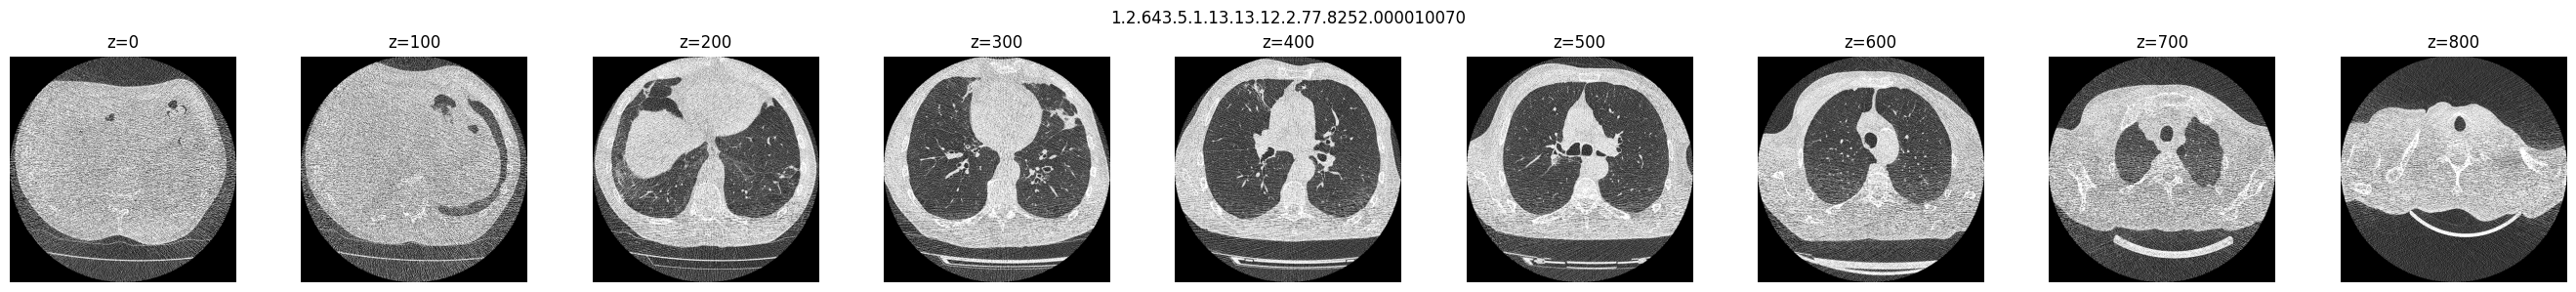

In [4]:
import pydicom
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def load_dicom_volume(series_dir):
    """Загружает серию DICOM файлов как 3D volume."""
    files = sorted(Path(series_dir).glob("*.dcm"))
    slices = [pydicom.dcmread(f) for f in files]
    # Сортировка по позиции среза
    slices.sort(key=lambda s: float(s.ImagePositionPatient[2]))
    volume = np.stack([s.pixel_array * s.RescaleSlope + s.RescaleIntercept for s in slices])
    return volume  # shape: (Z, H, W) в единицах HU

def show_slices(volume, n=9, window_center=-600, window_width=1500, title=""):
    """Показывает n равномерно распределённых срезов с легочным окном."""
    wmin = window_center - window_width // 2
    wmax = window_center + window_width // 2
    vol_clipped = np.clip(volume, wmin, wmax)
    vol_norm = (vol_clipped - wmin) / (wmax - wmin)

    indices = np.linspace(0, len(volume) - 1, n, dtype=int)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    for ax, idx in zip(axes, indices):
        ax.imshow(vol_norm[idx], cmap="gray")
        ax.set_title(f"z={idx}")
        ax.axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

# Пример использования
data_dir = Path("data/mosmed/MosMedData-LDCT-LUNGCR-type I-v 1/studies")
study = sorted(data_dir.iterdir())[0]
series = sorted(study.iterdir())[0]

volume = load_dicom_volume(series)
print(f"Volume shape: {volume.shape}, HU range: [{volume.min():.0f}, {volume.max():.0f}]")
show_slices(volume, title=study.name[:40])

## run

In [5]:
PROMPT = """\
You are an expert CT radiologist. Carefully examine these chest/abdomen CT slices.

Look carefully for ANY pathological findings — anything a radiologist would flag in a clinical report.

Important:
- Normal anatomical variants are NOT pathology
- Age-related degenerative changes are NOT pathology
- Artifacts, noise, motion blur are NOT pathology
- Report ABNORMAL only for true structural pathology
- If is_abnormal is false, set confidence to 1

First, describe what you see in the "analysis" field. Then give your verdict.

{
  "analysis": "what you observe in these slices",
  "is_abnormal": true/false,
  "confidence": 1 (not reportable) / 2 (cannot exclude) / 3 (definite finding),
  "pathology_type": "covid" / "cancer" / "abdominal" / "other" / null
}
"""

EVAL_COMBOS = [
    ("axial", -600, 1500),   # легочное окно
    ("axial", 40, 400),      # мягкотканное окно
]

BASE = 50
GROUP_SIZE = 8
GROUP_STRIDE = GROUP_SIZE

RULES = [
    # {"conf": 3},              # достоверная находка
    # {"conf": 2, "run": 2},    # вероятная + подтверждена соседями
    {"ratio": 0.3},           # диффузная патология
]

In [6]:
DATA_DIR = "data/mosmed/MosMedData-LDCT-LUNGCR-type I-v 1"
STUDIES_DIR = os.path.join(DATA_DIR, "studies")

df_labels = pd.read_excel(os.path.join(DATA_DIR, "dataset_registry.xlsx"))
gt_map = dict(zip(df_labels["study_instance_anon"], df_labels["pathology"]))

study_dirs = sorted([
    d for d in Path(STUDIES_DIR).iterdir() if d.is_dir()
])

test_files = []
for d in study_dirs:
    gt_val = gt_map.get(d.name)
    gt = "ABNORMAL" if gt_val == 1 else "NORMAL" if gt_val == 0 else None
    test_files.append((str(d), gt))

# Случайная выборка (закомментируй для всех)
# random.seed(42)
# test_files = random.sample(test_files, min(20, len(test_files)))

print(f"Studies: {len(test_files)}")
print(f"  ABNORMAL: {sum(1 for _, g in test_files if g == 'ABNORMAL')}")
print(f"  NORMAL:   {sum(1 for _, g in test_files if g == 'NORMAL')}")

Studies: 100
  ABNORMAL: 50
  NORMAL:   50


In [7]:
import time, json, os
import numpy as np
import pandas as pd
from pathlib import Path

SAVE_PATH = "results_lungcr.csv"

done = set()
if os.path.exists(SAVE_PATH):
    done = set(pd.read_csv(SAVE_PATH)["file"].tolist())
    print(f"Resume: {len(done)} already done")

for i, (fname, gt) in enumerate(test_files):
    if fname in done:
        continue

    vol_3d = load_dicom_volume(fname)
    if vol_3d is None:
        print(f"[{i+1}/{len(test_files)}] {Path(fname).name} — SKIP: no DICOM")
        continue

    n_slices = vol_3d.shape[0]
    print(f"\n[{i+1}/{len(test_files)}] {Path(fname).name} | {n_slices} slices")
    t0 = time.time()

    all_planes = extract_planes(vol_3d)

    all_ratios, all_runs, all_confs = {}, {}, {}
    all_is_abnormal, all_ranges = {}, {}
    n_groups_total = 0

    for plane, center, width in EVAL_COMBOS:
        groups, ranges = prepare_uniform(
            all_planes[plane], center=center, width=width,
            group_size=GROUP_SIZE, group_stride=GROUP_STRIDE, base=BASE,
        )

        r = model.run(groups, prompt=PROMPT)
        key = f"{plane}_hu({center})"

        is_abn = r["is_abnormal"]
        confs = r["confidences"]
        abn_confs = [c for c, a in zip(confs, is_abn) if a]

        all_ratios[key] = r["abnormal_ratio"]
        all_runs[key] = longest_run(is_abn)
        all_confs[key] = max(abn_confs) if abn_confs else 0
        all_is_abnormal[key] = is_abn
        all_ranges[key] = ranges
        n_groups_total += len(groups)

    # === Финальный вердикт ===
    verdict = "NORMAL"
    triggered_rule = None
    triggered_key = None
    for key in all_ratios:
        hit, rule = check_rules(all_confs[key], all_runs[key], all_ratios[key], RULES)
        if hit:
            verdict = "ABNORMAL"
            triggered_rule = rule
            triggered_key = key
            break

    # === Вывод ===
    elapsed = round(time.time() - t0, 1)
    gt_str = f" (gt={gt})" if gt else ""
    match_str = ""
    if gt:
        match_str = " ✅" if verdict == gt else " ❌"

    print(f"  -> {verdict}{gt_str}{match_str} | {elapsed}s | groups={n_groups_total}")
    for key in all_ratios:
        n_abn = sum(all_is_abnormal[key])
        n_tot = len(all_is_abnormal[key])
        print(
            f"     {key}: {n_abn}/{n_tot} abnormal"
            f" | conf={all_confs[key]} run={all_runs[key]} ratio={all_ratios[key]:.2f}"
        )
    if triggered_rule:
        print(f"     triggered: {triggered_rule} on {triggered_key}")

    # === Сохранение ===
    row = {
        "file": fname,
        "label": gt,
        "verdict": verdict,
        "triggered_rule": json.dumps(triggered_rule),
        "triggered_key": triggered_key,
        "time": elapsed,
        "n_slices": n_slices,
        "n_groups_total": n_groups_total,
        **{f"{k}_ratio": v for k, v in all_ratios.items()},
        **{f"{k}_run": v for k, v in all_runs.items()},
        **{f"{k}_conf": v for k, v in all_confs.items()},
        **{f"{k}_is_abnormal": json.dumps(v) for k, v in all_is_abnormal.items()},
        **{f"{k}_ranges": json.dumps(v) for k, v in all_ranges.items()},
    }

    pd.DataFrame([row]).to_csv(
        SAVE_PATH, mode="a",
        header=not os.path.exists(SAVE_PATH), index=False,
    )
    done.add(fname)


[1/100] 1.2.643.5.1.13.13.12.2.77.8252.00001007020103130905041401130706 | 401 slices


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


INFO 03-24 13:53:32 [chat_utils.py:574] Detected the chat template content format to be 'openai'. You can set `--chat-template-content-format` to override this.


2026-03-24 13:54:28 [MODEL] INFO: ABNORMAL: 9/22 (41%) | 64s
2026-03-24 13:55:04 [MODEL] INFO: ABNORMAL: 4/22 (18%) | 29s


  -> ABNORMAL (gt=ABNORMAL) ✅ | 113.3s | groups=44
     axial_hu(-600): 9/22 abnormal | conf=3 run=5 ratio=0.41
     axial_hu(40): 4/22 abnormal | conf=3 run=2 ratio=0.18
     triggered: {'ratio': 0.3} on axial_hu(-600)

[2/100] 1.2.643.5.1.13.13.12.2.77.8252.00020801120805130807110203100907 | 394 slices


...

2026-03-24 14:27:45 [MODEL] INFO: ABNORMAL: 5/22 (23%) | 26s
2026-03-24 14:28:15 [MODEL] INFO: ABNORMAL: 5/22 (23%) | 29s


  -> NORMAL (gt=ABNORMAL) ❌ | 58.9s | groups=44
     axial_hu(-600): 5/22 abnormal | conf=3 run=3 ratio=0.23
     axial_hu(40): 5/22 abnormal | conf=3 run=3 ratio=0.23

[27/100] 1.2.643.5.1.13.13.12.2.77.8252.02140612130405140109140604141012 | 561 slices


2026-03-24 14:29:09 [MODEL] INFO: ABNORMAL: 5/22 (23%) | 29s
2026-03-24 14:29:49 [MODEL] INFO: ABNORMAL: 8/22 (36%) | 29s


  -> ABNORMAL (gt=NORMAL) ❌ | 90.5s | groups=44
     axial_hu(-600): 5/22 abnormal | conf=3 run=2 ratio=0.23
     axial_hu(40): 8/22 abnormal | conf=3 run=3 ratio=0.36
     triggered: {'ratio': 0.3} on axial_hu(40)

[28/100] 1.2.643.5.1.13.13.12.2.77.8252.03021300141211141506140808140804 | 1 slices


ValueError: too many values to unpack (expected 3)

,Metric,Value
0,Accuracy,0.519
1,Sensitivity,0.562
2,Specificity,0.455
3,PPV (Precision),0.600
4,NPV,0.417
5,ROC AUC,0.562


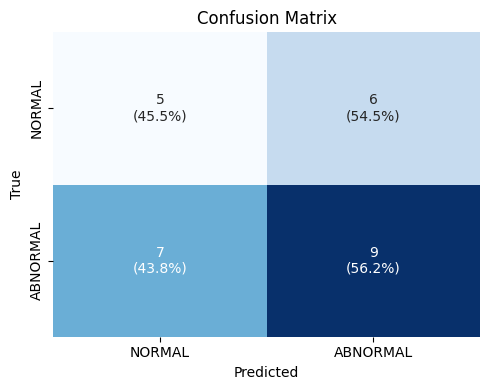

In [10]:
df_res = pd.read_csv("results_lungcr.csv")
show_metrics(df_res)

## Andrey

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [2]:
%load_ext autoreload
%autoreload 2

from andrey.lung_cancer_experiments_v2 import load_lc_registry, prepare_lc_subset, run_lung_cancer_benchmark_v2

df_registry = load_lc_registry()
df_take = prepare_lc_subset(df_registry)
df_results = run_lung_cancer_benchmark_v2(df_take=df_take)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

MosMed lung cancer studies: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [2:38:19<00:00, 94.99s/it]


=== Ranking / classification by anomaly_share ===
ROC-AUC: 0.7332
Best threshold by F1: 0.07
Precision: 0.608, Recall: 0.900, F1: 0.726

=== Metrics for study-level decisions ===
decision_by_fraction {'roc_auc': np.float64(0.6900000000000002), 'accuracy': 0.69, 'precision': 0.6557377049180327, 'recall': 0.8, 'f1': 0.7207207207207207}
decision_by_consecutive {'roc_auc': np.float64(0.55), 'accuracy': 0.55, 'precision': 0.5274725274725275, 'recall': 0.96, 'f1': 0.6808510638297872}
decision_by_parts {'roc_auc': np.float64(0.5599999999999999), 'accuracy': 0.56, 'precision': 0.5375, 'recall': 0.86, 'f1': 0.6615384615384615}


In [3]:
import ast
import itertools
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support, accuracy_score

df = pd.read_csv('output/lung_cancer_results_v2_axial-sagittal-coronal.csv')
df['axis_labels'] = df['axis_labels'].apply(ast.literal_eval)

y = df['target'].values   # или df['pathology'].values
axes_all = ['axial', 'sagittal', 'coronal']


# cell 2
def clf_metrics(y_true, y_pred, y_score=None):
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )
    return {
        'roc_auc': roc_auc_score(y_true, y_score) if y_score is not None and len(np.unique(y_score)) > 1 else np.nan,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': p,
        'recall': r,
        'f1': f1,
    }

def best_f1_threshold(y_true, y_score):
    best_t, best_f1 = 0.5, -1
    for t in np.unique(y_score):
        pred = (y_score >= t).astype(int)
        f1 = precision_recall_fscore_support(
            y_true, pred, average='binary', zero_division=0
        )[2]
        if f1 > best_f1:
            best_t, best_f1 = t, f1
    return best_t, best_f1

def anomaly_share_for_axes(axis_labels_dict, axes_subset):
    vals = []
    for ax in axes_subset:
        vals.extend(axis_labels_dict.get(ax, []))
    return np.mean(vals) if len(vals) else np.nan


# cell 3
axis_combos = []
for r in range(1, len(axes_all) + 1):
    axis_combos += list(itertools.combinations(axes_all, r))

combo_names = ['+'.join(c) for c in axis_combos]
print(combo_names)


# cell 4
rows = []

for combo in axis_combos:
    combo_name = '+'.join(combo)
    
    score = df['axis_labels'].apply(lambda d: anomaly_share_for_axes(d, combo)).values
    roc_auc = roc_auc_score(y, score) if len(np.unique(score)) > 1 else np.nan
    
    best_t, _ = best_f1_threshold(y, score)
    pred = (score >= best_t).astype(int)
    
    rows.append({
        'axes': combo_name,
        'best_threshold': best_t,
        **clf_metrics(y, pred, score)
    })

metrics_df = pd.DataFrame(rows).sort_values('f1', ascending=False)
display(metrics_df)


# cell 5
def has_n_consecutive(arr, n):
    cnt = 0
    for v in arr:
        cnt = cnt + 1 if v == 1 else 0
        if cnt >= n:
            return 1
    return 0

def pred_by_consecutive(axis_labels_dict, axes_subset, n):
    return int(any(has_n_consecutive(axis_labels_dict.get(ax, []), n) for ax in axes_subset))

rows = []

for combo in axis_combos:
    combo_name = '+'.join(combo)
    for n in range(1, 4):
        pred = df['axis_labels'].apply(lambda d: pred_by_consecutive(d, combo, n)).values
        rows.append({
            'axes': combo_name,
            'n_consecutive': n,
            **clf_metrics(y, pred, pred)
        })

consecutive_df = pd.DataFrame(rows).sort_values(['axes', 'f1'], ascending=[True, False])
display(consecutive_df)

['axial', 'sagittal', 'coronal', 'axial+sagittal', 'axial+coronal', 'sagittal+coronal', 'axial+sagittal+coronal']


,axes,best_threshold,roc_auc,accuracy,precision,recall,f1
0,axial,0.174274,1.00,1.0,1.000000,1.0,1.000000
1,sagittal,0.050781,1.00,1.0,1.000000,1.0,1.000000
3,axial+sagittal,0.110664,1.00,1.0,1.000000,1.0,1.000000
6,axial+sagittal+coronal,0.113543,1.00,1.0,1.000000,1.0,1.000000
4,axial+coronal,0.141053,1.00,1.0,1.000000,1.0,1.000000
2,coronal,0.089844,0.84,0.9,0.833333,1.0,0.909091
5,sagittal+coronal,0.076172,0.92,0.9,0.833333,1.0,0.909091


,axes,n_consecutive,roc_auc,accuracy,precision,recall,f1
0,axial,1,NaN,0.5,0.500000,1.0,0.666667
1,axial,2,NaN,0.5,0.500000,1.0,0.666667
2,axial,3,NaN,0.5,0.500000,1.0,0.666667
12,axial+coronal,1,NaN,0.5,0.500000,1.0,0.666667
13,axial+coronal,2,NaN,0.5,0.500000,1.0,0.666667
14,axial+coronal,3,NaN,0.5,0.500000,1.0,0.666667
9,axial+sagittal,1,NaN,0.5,0.500000,1.0,0.666667
10,axial+sagittal,2,NaN,0.5,0.500000,1.0,0.666667
11,axial+sagittal,3,NaN,0.5,0.500000,1.0,0.666667
18,axial+sagittal+coronal,1,NaN,0.5,0.500000,1.0,0.666667


# Dataset of Computed Tomography Angiography (CTA) with Signs of Calcification, Thrombosis, Dilation, and Aneurysm, Including Segmented Abdominal Aorta Lumen and Wall
- https://mosmed.ai/en/datasets/datasets/nabor-dannih-kompyuterno-tomograficheskoi-angiografii-s-priznakami-kaltsinoza-tromboza-dilatatsii-i-anevrizmi-i-soderzhaschii-segmentatsiyu-prosveta-i-stenki-bryushnogo-otdela-aorti/

## unzip

In [6]:
import os, zipfile
import numpy as np
import pandas as pd
import nibabel as nib

ARCHIVE = "data/mosmed/НД_КТА_ОБП_аорта.zip"
EXTRACT_DIR = "data/mosmed/НД_КТА_ОБП_аорта"

os.makedirs(EXTRACT_DIR, exist_ok=True)
with zipfile.ZipFile(ARCHIVE) as z:
    z.extractall(EXTRACT_DIR)

Studies: 100 | {'ABNORMAL': 61, 'NORMAL': 39}


In [5]:
STUDIES_DIR = os.path.join(EXTRACT_DIR, "studies")
df_labels = pd.read_excel(os.path.join(EXTRACT_DIR, "classification.xlsx"))
df_labels.columns = ["num", "aneurysm", "diameter_mm", "calcification", "thrombosis"]
df_labels["filename"] = "orig" + df_labels["num"].astype(str) + ".nii"
df_labels["gt"] = np.where(df_labels[["aneurysm", "calcification", "thrombosis"]].any(axis=1), "ABNORMAL", "NORMAL")

print(f"Studies: {len(df_labels)} | {df_labels['gt'].value_counts().to_dict()}")

Studies: 100 | {'ABNORMAL': 61, 'NORMAL': 39}


## visualization

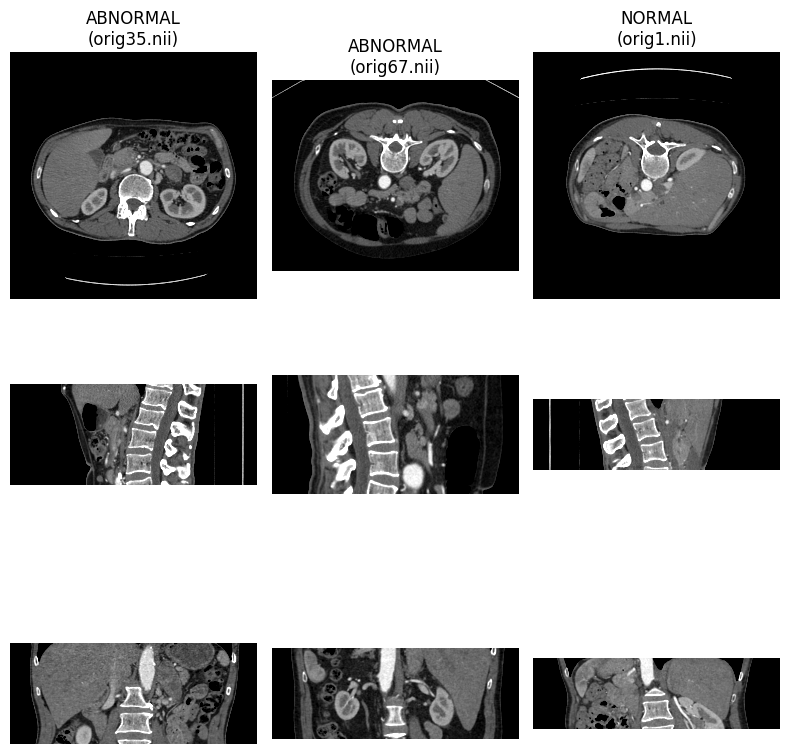

In [8]:
def show_projections(samples, hu_window=(40, 400), studies_dir=STUDIES_DIR):
    """Показывает 3 проекции для каждого сэмпла."""
    c, w = hu_window
    plane_names = ["axial", "coronal", "sagittal"]

    fig, axes = plt.subplots(len(plane_names), len(samples), figsize=(8, 3 * len(plane_names)))

    for col, (label, fname) in enumerate(samples):
        vol = nib.load(os.path.join(studies_dir, fname)).get_fdata()
        planes = extract_planes(vol)

        for row, name in enumerate(plane_names):
            plane_vol = planes[name]
            mid = plane_vol.shape[0] // 2
            s = plane_vol[mid]

            ax = axes[row, col]
            ax.imshow(s, cmap="gray", vmin=c - w//2, vmax=c + w//2)
            if col == 0:
                ax.set_ylabel(name.capitalize(), fontsize=11)
            if row == 0:
                ax.set_title(f"{label}\n({fname})")
            ax.axis("off")

    plt.tight_layout()
    plt.show()

samples = [
    ("ABNORMAL", "orig35.nii"),
    ("ABNORMAL", "orig67.nii"),
    ("NORMAL", "orig1.nii"),
]

# show_projections(samples, hu_window=(40, 400))
show_projections(samples, hu_window=(100, 500))

## validation

In [5]:
PROMPT = """\
You are an expert CT radiologist. Carefully examine these chest/abdomen CT slices.

Look carefully for ANY pathological findings — anything a radiologist would flag in a clinical report.

Important:
- Normal anatomical variants are NOT pathology
- Age-related degenerative changes are NOT pathology
- Artifacts, noise, motion blur are NOT pathology
- Report ABNORMAL only for true structural pathology
- If is_abnormal is false, set confidence to 1

First, describe what you see in the "analysis" field. Then give your verdict.

{
  "analysis": "what you observe in these slices",
  "is_abnormal": true/false,
  "confidence": 1 (not reportable) / 2 (cannot exclude) / 3 (definite finding),
  "pathology_type": "covid" / "cancer" / "abdominal" / "other" / null
}
"""

EVAL_COMBOS = [
    ("axial", -600, 1500),   # легочное окно
    ("axial", 40, 400),      # мягкотканное окно
]

BASE = 50
GROUP_SIZE = 8
GROUP_STRIDE = GROUP_SIZE

RULES = [
    # {"conf": 3},              # достоверная находка
    # {"conf": 2, "run": 2},    # вероятная + подтверждена соседями
    {"ratio": 0.3},           # диффузная патология
]

In [9]:
DATA_DIR = "data/mosmed/НД_КТА_ОБП_аорта"
STUDIES_DIR = os.path.join(DATA_DIR, "studies")

df_labels = pd.read_excel(os.path.join(DATA_DIR, "classification.xlsx"))
df_labels.columns = ["num", "aneurysm", "diameter_mm", "calcification", "thrombosis"]
df_labels["filename"] = "orig" + df_labels["num"].astype(str) + ".nii"
df_labels["gt"] = np.where(
    df_labels[["aneurysm", "calcification", "thrombosis"]].any(axis=1),
    "ABNORMAL", "NORMAL"
)

gt_map = dict(zip(df_labels["filename"], df_labels["gt"]))

all_files = sorted(f for f in os.listdir(STUDIES_DIR) if f.startswith("orig") and f.endswith(".nii"))
test_files = []
for f in all_files:
    if f.endswith(".nii"):
        gt = gt_map.get(f)
        test_files.append((f, gt))

# Случайная выборка (закомментируй для всех)
# random.seed(42)
# test_files = random.sample(test_files, min(20, len(test_files)))

print(f"Studies: {len(test_files)}")
print(f"  ABNORMAL: {sum(1 for _, g in test_files if g == 'ABNORMAL')}")
print(f"  NORMAL:   {sum(1 for _, g in test_files if g == 'NORMAL')}")

Studies: 100
  ABNORMAL: 61
  NORMAL:   39


In [11]:
SAVE_PATH = "results_aorta.csv"

done = set()
if os.path.exists(SAVE_PATH):
    done = set(pd.read_csv(SAVE_PATH)["file"].tolist())
    print(f"Resume: {len(done)} already done")

for i, (fname, gt) in enumerate(test_files):
    if fname in done:
        continue

    vol_3d = nib.load(os.path.join(STUDIES_DIR, fname)).get_fdata().astype(np.float32)
    n_slices = vol_3d.shape[0]
    print(f"\n[{i+1}/{len(test_files)}] {fname} | {n_slices} slices")
    t0 = time.time()

    all_planes = extract_planes(vol_3d)

    all_ratios, all_runs, all_confs = {}, {}, {}
    all_is_abnormal, all_ranges = {}, {}
    n_groups_total = 0

    for plane, center, width in EVAL_COMBOS:
        groups, ranges = prepare_uniform(
            all_planes[plane], center=center, width=width,
            group_size=GROUP_SIZE, group_stride=GROUP_STRIDE, base=BASE,
        )

        r = model.run(groups, prompt=PROMPT)
        key = f"{plane}_hu({center})"

        is_abn = r["is_abnormal"]
        confs = r["confidences"]
        abn_confs = [c for c, a in zip(confs, is_abn) if a]

        all_ratios[key] = r["abnormal_ratio"]
        all_runs[key] = longest_run(is_abn)
        all_confs[key] = max(abn_confs) if abn_confs else 0
        all_is_abnormal[key] = is_abn
        all_ranges[key] = ranges
        n_groups_total += len(groups)

    # === Финальный вердикт ===
    verdict = "NORMAL"
    triggered_rule = None
    triggered_key = None
    for key in all_ratios:
        hit, rule = check_rules(all_confs[key], all_runs[key], all_ratios[key], RULES)
        if hit:
            verdict = "ABNORMAL"
            triggered_rule = rule
            triggered_key = key
            break

    # === Вывод ===
    elapsed = round(time.time() - t0, 1)
    gt_str = f" (gt={gt})" if gt else ""
    match_str = ""
    if gt:
        match_str = " ✅" if verdict == gt else " ❌"

    print(f"  -> {verdict}{gt_str}{match_str} | {elapsed}s | groups={n_groups_total}")
    for key in all_ratios:
        n_abn = sum(all_is_abnormal[key])
        n_tot = len(all_is_abnormal[key])
        print(
            f"     {key}: {n_abn}/{n_tot} abnormal"
            f" | conf={all_confs[key]} run={all_runs[key]} ratio={all_ratios[key]:.2f}"
        )
    if triggered_rule:
        print(f"     triggered: {triggered_rule} on {triggered_key}")

    # === Сохранение ===
    row = {
        "file": fname,
        "label": gt,
        "verdict": verdict,
        "triggered_rule": json.dumps(triggered_rule),
        "triggered_key": triggered_key,
        "time": elapsed,
        "n_slices": n_slices,
        "n_groups_total": n_groups_total,
        **{f"{k}_ratio": v for k, v in all_ratios.items()},
        **{f"{k}_run": v for k, v in all_runs.items()},
        **{f"{k}_conf": v for k, v in all_confs.items()},
        **{f"{k}_is_abnormal": json.dumps(v) for k, v in all_is_abnormal.items()},
        **{f"{k}_ranges": json.dumps(v) for k, v in all_ranges.items()},
    }

    pd.DataFrame([row]).to_csv(
        SAVE_PATH, mode="a",
        header=not os.path.exists(SAVE_PATH), index=False,
    )
    done.add(fname)


[1/100] orig1.nii | 512 slices


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


INFO 03-24 16:48:40 [chat_utils.py:574] Detected the chat template content format to be 'openai'. You can set `--chat-template-content-format` to override this.


2026-03-24 16:49:25 [MODEL] INFO: ABNORMAL: 9/19 (47%) | 52s
2026-03-24 16:49:50 [MODEL] INFO: ABNORMAL: 7/19 (37%) | 20s


  -> ABNORMAL (gt=NORMAL) ❌ | 83.4s | groups=38
     axial_hu(-600): 9/19 abnormal | conf=3 run=7 ratio=0.47
     axial_hu(40): 7/19 abnormal | conf=3 run=6 ratio=0.37
     triggered: {'ratio': 0.3} on axial_hu(-600)

[2/100] orig10.nii | 512 slices


...

  -> NORMAL (gt=ABNORMAL) ❌ | 28.7s | groups=26
     axial_hu(-600): 1/13 abnormal | conf=3 run=1 ratio=0.08
     axial_hu(40): 1/13 abnormal | conf=3 run=1 ratio=0.08

[99/100] orig98.nii | 512 slices


2026-03-24 18:12:14 [MODEL] INFO: ABNORMAL: 2/18 (11%) | 18s
2026-03-24 18:12:37 [MODEL] INFO: ABNORMAL: 2/18 (11%) | 18s


  -> NORMAL (gt=NORMAL) ✅ | 48.4s | groups=36
     axial_hu(-600): 2/18 abnormal | conf=3 run=2 ratio=0.11
     axial_hu(40): 2/18 abnormal | conf=3 run=1 ratio=0.11

[100/100] orig99.nii | 512 slices


2026-03-24 18:13:17 [MODEL] INFO: ABNORMAL: 8/22 (36%) | 31s
2026-03-24 18:13:56 [MODEL] INFO: ABNORMAL: 9/22 (41%) | 33s


  -> ABNORMAL (gt=NORMAL) ❌ | 79.1s | groups=44
     axial_hu(-600): 8/22 abnormal | conf=3 run=5 ratio=0.36
     axial_hu(40): 9/22 abnormal | conf=3 run=5 ratio=0.41
     triggered: {'ratio': 0.3} on axial_hu(-600)


,Metric,Value
0,Accuracy,0.490
1,Sensitivity,0.426
2,Specificity,0.590
3,PPV (Precision),0.619
4,NPV,0.397
5,ROC AUC,0.495


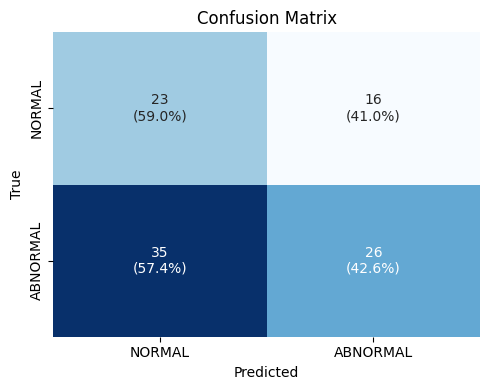

In [12]:
df_res = pd.read_csv("results_aorta.csv")
show_metrics(df_res)

In [13]:
1

1

# RSNA Abdominal Trauma Detection PNG pt1
- https://www.kaggle.com/datasets/theoviel/rsna-abdominal-trauma-detection-png-pt1

# DS26AID_CT_ HACK_PATOLOGY_CHEST_ORGANS_1.0.0

## unzip

In [1]:
import os, zipfile
from pathlib import Path
from tqdm import tqdm

ARCHIVE = Path("data/mosmed/DS26AID_CT_ HACK_PATOLOGY_CHEST_ORGANS_1.0.0.zip")
EXTRACT_DIR = ARCHIVE.with_suffix("")

# Распаковка основного архива с прогрессом
with zipfile.ZipFile(ARCHIVE) as z:
    members = z.namelist()
    for m in tqdm(members, desc="Main archive"):
        z.extract(m, ARCHIVE.parent)

# Распаковка вложенных архивов (каждый = исследование)
inner_zips = sorted(EXTRACT_DIR.rglob("*.zip"))
studies_dir = EXTRACT_DIR / "studies"
studies_dir.mkdir(exist_ok=True)

Studies: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 410/410 [09:40<00:00,  1.42s/it]

Done: 410 studies


In [ ]:
for sz in tqdm(inner_zips, desc="Studies"):
    study_dir = studies_dir / sz.stem
    if study_dir.exists():
        continue
    with zipfile.ZipFile(sz) as z:
        z.extractall(study_dir)

# Статистика
study_dirs = sorted([d for d in studies_dir.iterdir() if d.is_dir()])
print(f"Done: {len(study_dirs)} studies")

## visualization

In [39]:
from preprocessing import extract_planes, hu_to_pil
import nibabel as nib

# Берём первое исследование
study_dirs = sorted([d for d in studies_dir.iterdir() if d.is_dir()])
study = study_dirs[0]
print(f"Study: {study.name}")

# Загружаем volume через нашу функцию
volume = load_dicom_volume(study)  # (Z, H, W) в HU
print(f"Shape: {volume.shape}, HU range: [{volume.min():.0f}, {volume.max():.0f}]")

# Показываем срезы в lung window
n = 9
indices = np.linspace(0, len(volume) - 1, n, dtype=int)

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for ax, idx in zip(axes.flatten(), indices):
    ax.imshow(volume[idx], cmap="gray", vmin=-1350, vmax=150)  # lung window
    ax.set_title(f"z={idx}")
    ax.axis("off")

plt.suptitle(study.name[:40])
plt.tight_layout()
plt.show()

NameError: name 'studies_dir' is not defined

## inference

In [9]:
PROMPT = """\
Role: Expert CT radiologist.
Task: Screen this CT slice for ANY pathological findings.
Rules: Ignore normal anatomy, age-related changes, and artifacts (noise, motion, hardware).

Output ONLY raw JSON (no markdown):
{
  "analysis": "<What you see in this slice>",
  "is_abnormal": <true/false>,
  "confidence": <1: Uncertain, 2: Likely, 3: Definite>,
  "pathology_type": <"covid"|"cancer"|"abdominal"|"other"|null>
}
"""


EVAL_COMBOS = [
    ("axial", -600, 1500),   # легочное окно
    ("axial", 40, 400),      # мягкотканное окно
    # ("coronal", -600, 1500), # корональное легочное окно
]

BASE = 50
GROUP_SIZE = 1
GROUP_STRIDE = GROUP_SIZE

RUN_THRESHOLD = None
RATIO_THRESHOLD = 0.3

In [10]:
import pydicom
import numpy as np
from pathlib import Path

studies_dir = Path("data/mosmed/DS26AID_CT_ HACK_PATOLOGY_CHEST_ORGANS_1.0.0/studies")
study_dirs = sorted([d for d in studies_dir.iterdir() if d.is_dir()])
print(f"Total studies: {len(study_dirs)}")

Total studies: 410


In [37]:
def load_dicom_volume(study_path):
    # ищем все файлы рекурсивно (DICOM часто без расширения)
    dcm_files = []
    for f in study_path.rglob("*"):
        if f.is_file():
            dcm_files.append(f)
    
    slices = []
    for f in dcm_files:
        try:
            ds = pydicom.dcmread(f)
            if hasattr(ds, "pixel_array"):
                slices.append(ds)
        except:
            continue
    
    if not slices:
        raise ValueError("No DICOM slices found")
    
    slices.sort(key=lambda s: float(s.ImagePositionPatient[2]))
    volume = np.stack([s.pixel_array.astype(np.float32) for s in slices])
    intercept = float(getattr(slices[0], "RescaleIntercept", 0))
    slope = float(getattr(slices[0], "RescaleSlope", 1))
    return volume * slope + intercept

In [38]:
import logging
from tqdm import tqdm

class TqdmLoggingHandler(logging.Handler):
    def emit(self, record):
        msg = self.format(record)
        tqdm.write(msg)

model_logger = logging.getLogger("medscreen.model")
model_logger.handlers.clear()
handler = TqdmLoggingHandler()
handler.setFormatter(logging.Formatter("%(asctime)s [MODEL] %(levelname)s: %(message)s"))
model_logger.addHandler(handler)
model_logger.propagate = False
model_logger.setLevel(logging.INFO)

from preprocessing import extract_planes, prepare_uniform

def longest_run(labels):
    best = cur = 0
    for x in labels:
        if x:
            cur += 1
            best = max(best, cur)
        else:
            cur = 0
    return best

In [39]:
import time, json, os
import numpy as np
import pydicom
from pathlib import Path

SAVE_PATH = "result_ds26aid.csv"

done = set()
if os.path.exists(SAVE_PATH):
    done = set(pd.read_csv(SAVE_PATH)["study"].tolist())
    print(f"Resume: {len(done)} already done")

for i, study_dir in enumerate(tqdm(study_dirs)):
    study_name = study_dir.name
    if study_name in done:
        continue

    t0 = time.time()
    try:
        vol_3d = load_dicom_volume(study_dir)
    except Exception as e:
        tqdm.write(f"[{i+1}] {study_name} SKIP: {e}")
        continue

    all_planes = extract_planes(vol_3d)

    all_ratios, all_runs, all_ptypes = {}, {}, {}
    all_is_abnormal, all_ranges = {}, {}
    n_groups_total = 0

    for plane, center, width in EVAL_COMBOS:
        groups, ranges = prepare_uniform(
            all_planes[plane], center=center, width=width,
            group_size=GROUP_SIZE, group_stride=GROUP_STRIDE, base=BASE,
        )

        r = model.run(groups, prompt=PROMPT)
        key = f"{plane}_hu({center})"

        all_ratios[key] = r["abnormal_ratio"]
        all_runs[key] = longest_run(r["is_abnormal"])
        all_is_abnormal[key] = r["is_abnormal"]
        all_ranges[key] = ranges
        all_ptypes[key] = [p for p in r["pathology_types"] if p]
        n_groups_total += len(groups)

    # Вердикт: простая логика по ratio/run
    max_ratio = max(all_ratios.values()) if all_ratios else 0
    max_run = max(all_runs.values()) if all_runs else 0

    if RUN_THRESHOLD is None:
        verdict = "ABNORMAL" if max_ratio >= RATIO_THRESHOLD else "NORMAL"
    else:
        verdict = "ABNORMAL" if (max_run >= RUN_THRESHOLD or max_ratio >= RATIO_THRESHOLD) else "NORMAL"

    elapsed = round(time.time() - t0, 1)

    # Типы патологий из всех комбинаций
    found_types = set()
    for pts in all_ptypes.values():
        found_types.update(pts)

    tqdm.write(
        f"[{i+1}/{len(study_dirs)}] {study_name} -> {verdict} ({elapsed}s) "
        f"| types: {found_types or 'none'} | "
        + " ".join(f"{k}: ratio={all_ratios[k]:.2f} run={all_runs[k]}" for k in all_ratios)
    )

    row = {
        "study": study_name,
        "verdict": verdict,
        "time": elapsed,
        "n_groups_total": n_groups_total,
        "pathology_types": json.dumps(list(found_types)),
        **{f"{k}_ratio": v for k, v in all_ratios.items()},
        **{f"{k}_run": v for k, v in all_runs.items()},
        **{f"{k}_is_abnormal": json.dumps([int(x) for x in v]) for k, v in all_is_abnormal.items()},
        **{f"{k}_ranges": json.dumps(v) for k, v in all_ranges.items()},
    }

    pd.DataFrame([row]).to_csv(SAVE_PATH, mode="a", header=not os.path.exists(SAVE_PATH), index=False)
    done.add(study_name)

  0%|                                                                                                                                                                         | 0/410 [00:29<?, ?it/s]

2026-03-23 16:14:36,231 [MODEL] INFO: ABNORMAL: 15/171 (9%) | 23s


  0%|▍                                                                                                                                                              | 1/410 [00:58<6:38:43, 58.49s/it]

2026-03-23 16:15:04,964 [MODEL] INFO: ABNORMAL: 25/171 (15%) | 25s
[1/410] 1.2.826.0.1.3680043.8.498.10014916873833240105399022661231403191 -> NORMAL (58.5s) | types: none | axial_hu(-600): ratio=0.09 run=9 axial_hu(40): ratio=0.15 run=5


  0%|▍                                                                                                                                                              | 1/410 [01:34<6:38:43, 58.49s/it]

...

 98%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎  | 403/410 [8:53:01<08:38, 74.13s/it]

2026-03-24 01:07:07,939 [MODEL] INFO: ABNORMAL: 73/171 (43%) | 26s
[403/410] 1.2.826.0.1.3680043.8.498.97693891165853716308242913533081638254 -> ABNORMAL (74.0s) | types: none | axial_hu(-600): ratio=0.32 run=11 axial_hu(40): ratio=0.43 run=10


 98%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎  | 403/410 [8:53:47<08:38, 74.13s/it]

2026-03-24 01:07:54,485 [MODEL] INFO: ABNORMAL: 41/171 (24%) | 26s


 98%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎  | 403/410 [8:54:20<08:38, 74.13s/it]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [40]:
errors_df = pd.DataFrame(errors)
errors_df.head()
errors_df["error"].value_counts()

NameError: name 'errors' is not defined

In [ ]:
df = pd.read_csv(SAVE_PATH)
df[df["verdict"] == "ERROR"][["study_id", "error"]].head(20)
df[df["verdict"] == "ERROR"]["error"].value_counts()

In [ ]:
df = pd.read_csv(SAVE_PATH)
print(df.shape)
df.head(3)

In [ ]:
print(df["verdict"].value_counts(dropna=False))